In [ ]:
#%pip install pandas numpy matplotlib scikit-learn

In [30]:
# ============================================
# TÜRKİYE KÜTÜPHANE VE NÜFUS ANALİZİ
# Veri Bilimi Dönem Projesi
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import r2_score, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("="*70)
print("📊 TÜRKİYE KÜTÜPHANE VE NÜFUS ANALİZİ")
print("="*70)

📊 TÜRKİYE KÜTÜPHANE VE NÜFUS ANALİZİ


In [31]:
# ============================================
# 1. CSV DOSYALARINI YÜKLE
# ============================================

try:
    # Nüfus verisini oku
    df_pop = pd.read_csv('dataset/tablo_nüfus - t3.csv', encoding='utf-8')
    print("✅ Nüfus verisi yüklendi!")

    # Kütüphane verisini oku
    df_lib = pd.read_csv('dataset/tablo_kütüphane.xlsx - t5.csv', encoding='utf-8')
    print("✅ Kütüphane verisi yüklendi!")
    
except FileNotFoundError as e:
    print(f"❌ Dosya bulunamadı: {e}")
    print("📌 Dosya isimlerini kontrol edin:")
    print("   - 'dataset/tablo_nüfus - t3.csv'")
    print("   - 'dataset/tablo_kütüphane.xlsx - t5.csv'")
    exit()

print(f"\n📋 Nüfus verisi boyutu: {df_pop.shape[0]} satır, {df_pop.shape[1]} sütun")
print(f"📋 Kütüphane verisi boyutu: {df_lib.shape[0]} satır, {df_lib.shape[1]} sütun")

✅ Nüfus verisi yüklendi!
✅ Kütüphane verisi yüklendi!

📋 Nüfus verisi boyutu: 86 satır, 13 sütun
📋 Kütüphane verisi boyutu: 86 satır, 16 sütun


In [32]:
# ============================================
# 2. VERİ TEMİZLEME
# ============================================

print("\n" + "="*70)
print("🔧 VERİ TEMİZLEME")
print("="*70)

# Nüfus verisinde boş satırları temizle
df_pop = df_pop.dropna(how='all')
df_lib = df_lib.dropna(how='all')

# Son satırları temizle (kaynak bilgileri)
df_pop = df_pop[~df_pop['İl\nProvinces'].str.contains('TÜİK|TurkStat|Bilgi', na=False)]
df_lib = df_lib[~df_lib['İl                             Province'].str.contains('TÜİK|TurkStat|Kaynak|Source', na=False)]

# İlk sütun isimlerini düzenle
df_pop = df_pop.rename(columns={'İl\nProvinces': 'İl'})
df_lib = df_lib.rename(columns={'İl                             Province': 'İl'})

print("✅ Genel temizlik tamamlandı!")


🔧 VERİ TEMİZLEME
✅ Genel temizlik tamamlandı!


In [33]:
# Nüfus verisi sütunlarını düzenle
df_pop.columns = ['İl', 'Toplam_Nüfus', 'Erkek', 'Kadın', 'Unnamed_4', 
                  'Merkez_Toplam', 'Merkez_Erkek', 'Merkez_Kadın', 'Unnamed_8',
                  'Kırsal_Toplam', 'Kırsal_Erkek', 'Kırsal_Kadın', 'Nüfus_Yoğunluğu']

# Gereksiz sütunları kaldır
df_pop = df_pop.drop(['Unnamed_4', 'Unnamed_8'], axis=1)

# Kütüphane verisi sütunlarını düzenle
df_lib.columns = ['İl', 'Kütüphane_Sayısı', 'Yararlanan_Kişi', 'Kayıtlı_Üye', 
                  'Ödünç_Materyal', 'Toplam_Kitap', 'Genel', 'Felsefe', 'Din', 
                  'Sosyal_Bilim', 'Dil', 'Doğa_Bilim', 'Uygulamalı_Bilim', 
                  'Sanat', 'Edebiyat', 'Coğrafya']

print("✅ Sütun düzenleme tamamlandı!")

✅ Sütun düzenleme tamamlandı!


In [35]:
# 'Toplam-Total' satırını çıkar (nüfus verisinden)
df_pop = df_pop[df_pop['İl'] != 'Toplam-Total ']
df_pop = df_pop[df_pop['İl'] != 'Toplam-Total']

# Sayısal sütunları dönüştür (boşlukları kaldır)
for col in df_pop.columns[1:]:
    df_pop[col] = df_pop[col].astype(str).str.replace(' ', '').str.replace(',', '')
    df_pop[col] = pd.to_numeric(df_pop[col], errors='coerce')

for col in df_lib.columns[1:]:
    df_lib[col] = df_lib[col].astype(str).str.replace(' ', '').str.replace(',', '')
    df_lib[col] = pd.to_numeric(df_lib[col], errors='coerce')

# Eksik değerleri 0 ile doldur
df_pop.fillna(0, inplace=True)
df_lib.fillna(0, inplace=True)

# İl isimlerini temizle
df_pop['İl'] = df_pop['İl'].str.strip()
df_lib['İl'] = df_lib['İl'].str.strip()

print(f"✅ Temizlik tamamlandı!")
print(f"   Nüfus: {len(df_pop)} il")
print(f"   Kütüphane: {len(df_lib)} il")

✅ Temizlik tamamlandı!
   Nüfus: 82 il
   Kütüphane: 82 il


In [36]:
# ============================================
# 3. VERİLERİ BİRLEŞTİR VE YENİ DEĞİŞKENLER OLUŞTUR
# ============================================

print("\n" + "="*70)
print("🔗 VERİ BİRLEŞTİRME VE FEATURE ENGINEERING")
print("="*70)

# Verileri birleştir
df_merged = pd.merge(df_pop, df_lib, on='İl', how='inner')
df_merged.fillna(0, inplace=True)

# Yeni değişkenler ekle (Feature Engineering)
df_merged['Kisi_Basi_Kitap'] = df_merged['Toplam_Kitap'] / df_merged['Toplam_Nüfus']
df_merged['Kirsal_Oran'] = df_merged['Kırsal_Toplam'] / df_merged['Toplam_Nüfus']
df_merged['Kutuphane_Yogunluk'] = (df_merged['Kütüphane_Sayısı'] / df_merged['Toplam_Nüfus']) * 100000
df_merged['Odunc_Oran'] = df_merged['Ödünç_Materyal'] / df_merged['Toplam_Kitap']
df_merged['Kayitli_Oran'] = df_merged['Kayıtlı_Üye'] / df_merged['Toplam_Nüfus']

# Sonsuz değerleri temizle
df_merged.replace([np.inf, -np.inf], 0, inplace=True)

print(f"✅ {len(df_merged)} il başarıyla birleştirildi!")
print("\n📊 İlk 10 il:")
print(df_merged[['İl', 'Toplam_Nüfus', 'Kütüphane_Sayısı', 'Yararlanan_Kişi', 'Toplam_Kitap']].head(10))


🔗 VERİ BİRLEŞTİRME VE FEATURE ENGINEERING
✅ 81 il başarıyla birleştirildi!

📊 İlk 10 il:
               İl  Toplam_Nüfus  Kütüphane_Sayısı  Yararlanan_Kişi  \
0           Adana     2283609.0                21           152082   
1        Adıyaman      617821.0                13           693363   
2  Afyonkarahisar      751808.0                17           210340   
3            Ağrı      491489.0                 9           248640   
4          Amasya      342242.0                 8           222954   
5          Ankara     5910320.0                76           864595   
6         Antalya     2777677.0                22           402629   
7          Artvin      167531.0                 9            78682   
8           Aydın     1172107.0                22           361877   
9       Balıkesir     1284517.0                25           478697   

   Toplam_Kitap  
0        395623  
1        225919  
2        325641  
3        143374  
4        284947  
5       1135188  
6        4697

In [37]:
# ============================================
# 4. TEMEL İSTATİSTİKLER (EDA)
# ============================================

print("\n" + "="*70)
print("📊 TANIMLAYICI İSTATİSTİKLER")
print("="*70)

print("\n📈 Nüfus ve Kütüphane İstatistikleri:")
print(df_merged[['Toplam_Nüfus', 'Nüfus_Yoğunluğu', 'Kütüphane_Sayısı', 
                 'Yararlanan_Kişi', 'Toplam_Kitap', 'Kisi_Basi_Kitap']].describe().round(2))


📊 TANIMLAYICI İSTATİSTİKLER

📈 Nüfus ve Kütüphane İstatistikleri:
       Toplam_Nüfus  Nüfus_Yoğunluğu  Kütüphane_Sayısı  Yararlanan_Kişi  \
count         81.00            81.00             81.00            81.00   
mean     1062866.27           136.73             16.07        483884.80   
std      1919236.46           331.35             12.29        811398.13   
min        82836.00            11.00              3.00         27064.00   
25%       311635.00            44.00              9.00        140492.00   
50%       564123.00            63.00             13.00        277075.00   
75%      1123693.00           124.00             19.00        520719.00   
max     15754053.00          2943.00             76.00       6577638.00   

       Toplam_Kitap  Kisi_Basi_Kitap  
count         81.00            81.00  
mean      321494.19             0.51  
std       357301.33             0.31  
min        64964.00             0.10  
25%       176251.00             0.29  
50%       242853.00    

In [38]:
# ============================================
# 5. ARAŞTIRMA SORULARI VE BULGULAR
# ============================================

print("\n" + "="*70)
print("🔍 ARAŞTIRMA SORULARI VE BULGULAR")
print("="*70)

# SORU 1: Nüfus yoğunluğu ile kütüphane kullanımı ilişkisi
print("\n📌 SORU 1: Nüfus yoğunluğu ile kütüphane kullanımı arasında ilişki var mı?")
corr = df_merged['Nüfus_Yoğunluğu'].corr(df_merged['Yararlanan_Kişi'])
print(f"   Korelasyon katsayısı: {corr:.3f}")
if corr > 0.7:
    print("   ✅ Güçlü pozitif ilişki var! Yoğun nüfuslu illerde kütüphane kullanımı daha yüksek.")
elif corr > 0.4:
    print("   ⚠️ Orta düzeyde pozitif ilişki var.")
else:
    print("   ❌ Zayıf ilişki var.")

# SORU 2: Kişi başı kitap sayısı en yüksek iller
print("\n📌 SORU 2: Kişi başına düşen kitap sayısı en yüksek iller hangileri?")
top_kisi_basi = df_merged.nlargest(5, 'Kisi_Basi_Kitap')[['İl', 'Kisi_Basi_Kitap', 'Kütüphane_Sayısı', 'Kirsal_Oran']]
for i, (_, row) in enumerate(top_kisi_basi.iterrows(), 1):
    print(f"   {i}. {row['İl']}: {row['Kisi_Basi_Kitap']:.3f} kitap/kişi "
          f"({row['Kütüphane_Sayısı']} kütüphane, Kırsal: {row['Kirsal_Oran']:.1%})")

# SORU 3: Kitap türleri dağılımı
print("\n📌 SORU 3: Hangi kitap türü daha baskın?")
kitap_turleri = {
    'Edebiyat': df_merged['Edebiyat'].sum(),
    'Sosyal Bilim': df_merged['Sosyal_Bilim'].sum(),
    'Doğa Bilim': df_merged['Doğa_Bilim'].sum(),
    'Sanat': df_merged['Sanat'].sum(),
    'Felsefe': df_merged['Felsefe'].sum()
}
toplam = sum(kitap_turleri.values())
print(f"   🏆 En çok kitap türü: {max(kitap_turleri, key=kitap_turleri.get)}")
for tur, sayi in sorted(kitap_turleri.items(), key=lambda x: x[1], reverse=True):
    print(f"     • {tur}: {sayi:,.0f} ({sayi/toplam*100:.1f}%)")


🔍 ARAŞTIRMA SORULARI VE BULGULAR

📌 SORU 1: Nüfus yoğunluğu ile kütüphane kullanımı arasında ilişki var mı?
   Korelasyon katsayısı: 0.820
   ✅ Güçlü pozitif ilişki var! Yoğun nüfuslu illerde kütüphane kullanımı daha yüksek.

📌 SORU 2: Kişi başına düşen kitap sayısı en yüksek iller hangileri?
   1. Nevşehir: 1.392 kitap/kişi (25 kütüphane, Kırsal: 33.6%)
   2. Tunceli: 1.390 kitap/kişi (7 kütüphane, Kırsal: 33.0%)
   3. Bayburt: 1.321 kitap/kişi (3 kütüphane, Kırsal: 34.1%)
   4. Isparta: 1.248 kitap/kişi (32 kütüphane, Kırsal: 24.2%)
   5. Çankırı: 1.181 kitap/kişi (14 kütüphane, Kırsal: 30.6%)

📌 SORU 3: Hangi kitap türü daha baskın?
   🏆 En çok kitap türü: Edebiyat
     • Edebiyat: 12,403,121 (62.3%)
     • Sosyal Bilim: 4,960,942 (24.9%)
     • Sanat: 1,018,656 (5.1%)
     • Felsefe: 962,712 (4.8%)
     • Doğa Bilim: 563,642 (2.8%)



📊 GÖRSELLEŞTİRMELER OLUŞTURULUYOR...


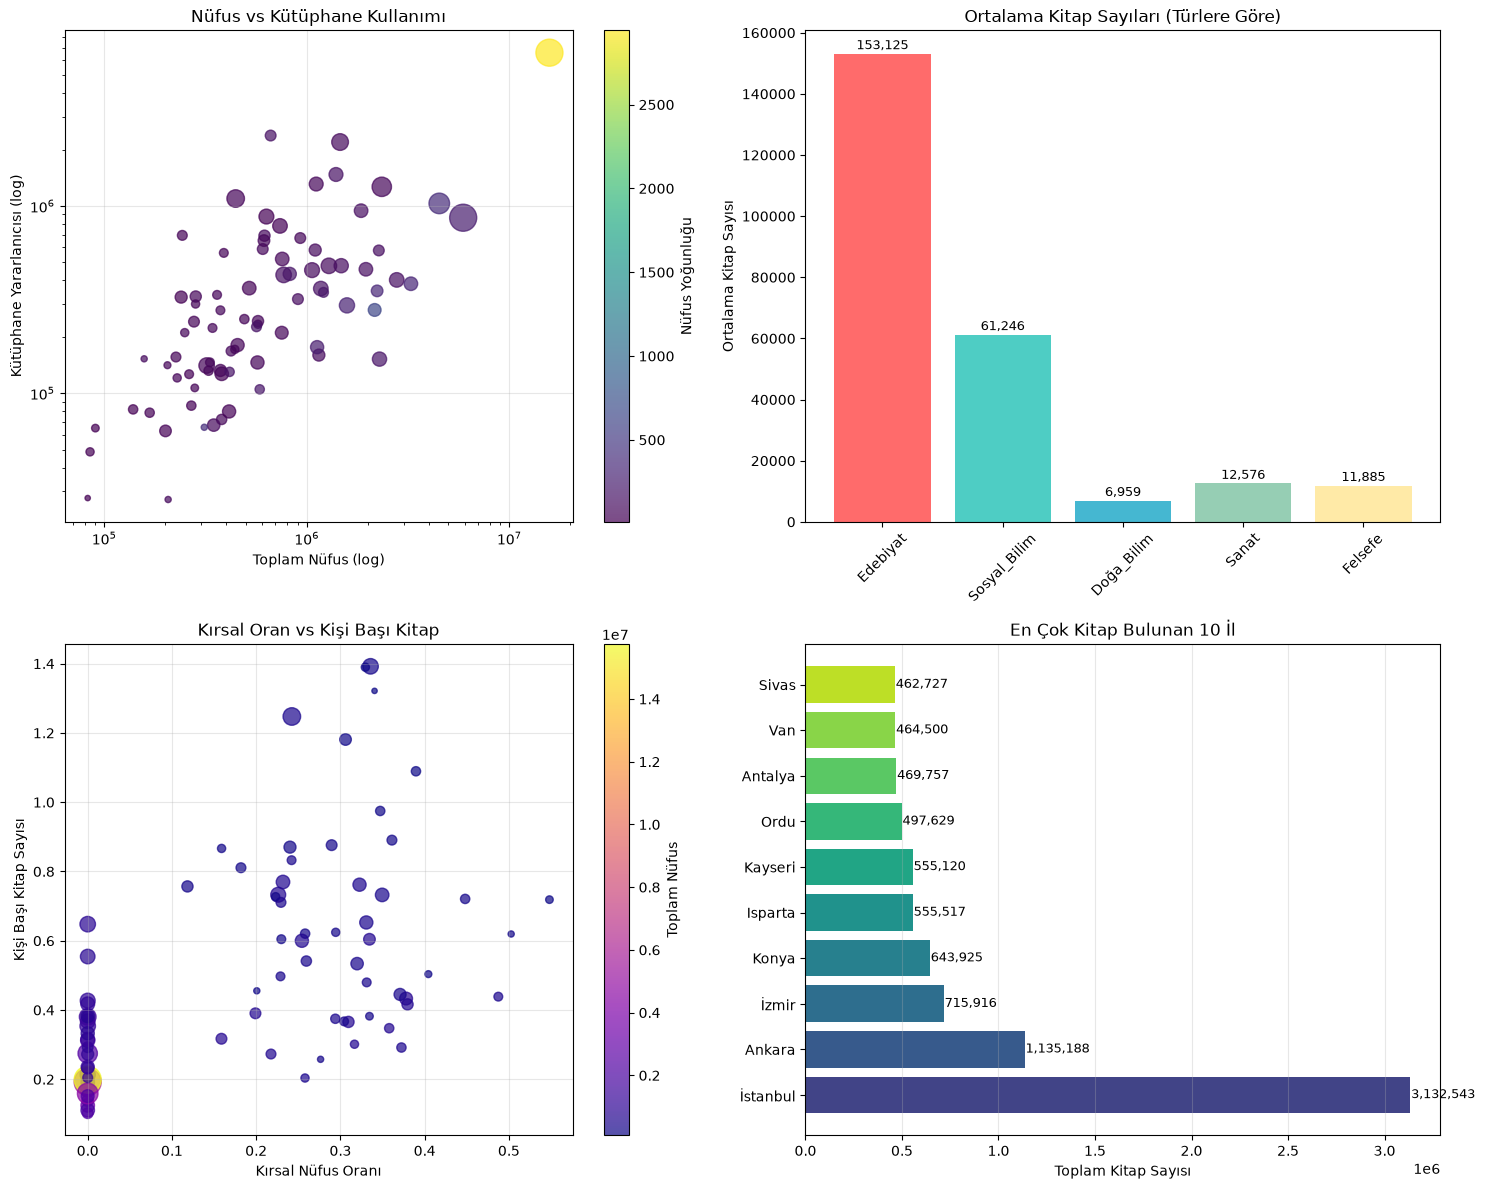

✅ Görselleştirmeler tamamlandı!


In [41]:
# ============================================
# 6. GÖRSELLEŞTİRMELER (TÜM GRAFİKLER TEK HÜCREDE)
# ============================================

print("\n" + "="*70)
print("📊 GÖRSELLEŞTİRMELER OLUŞTURULUYOR...")
print("="*70)

plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Grafik 1: Nüfus vs Kütüphane Kullanımı (Scatter Plot)
ax1 = axes[0, 0]
scatter = ax1.scatter(df_merged['Toplam_Nüfus'], df_merged['Yararlanan_Kişi'], 
                      alpha=0.7, s=df_merged['Kütüphane_Sayısı']*5,
                      c=df_merged['Nüfus_Yoğunluğu'], cmap='viridis')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('Toplam Nüfus (log)')
ax1.set_ylabel('Kütüphane Yararlanıcısı (log)')
ax1.set_title('Nüfus vs Kütüphane Kullanımı')
ax1.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax1, label='Nüfus Yoğunluğu')

# Grafik 2: Kitap Türleri (Bar Plot)
ax2 = axes[0, 1]
turler = ['Edebiyat', 'Sosyal_Bilim', 'Doğa_Bilim', 'Sanat', 'Felsefe']
ortalama = [df_merged['Edebiyat'].mean(), df_merged['Sosyal_Bilim'].mean(),
            df_merged['Doğa_Bilim'].mean(), df_merged['Sanat'].mean(),
            df_merged['Felsefe'].mean()]
bars = ax2.bar(turler, ortalama, color=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7'])
ax2.set_title('Ortalama Kitap Sayıları (Türlere Göre)')
ax2.set_ylabel('Ortalama Kitap Sayısı')
ax2.tick_params(axis='x', rotation=45)
for bar, val in zip(bars, ortalama):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, 
             f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# Grafik 3: Kırsal Oran vs Kişi Başı Kitap (Scatter Plot)
ax3 = axes[1, 0]
scatter2 = ax3.scatter(df_merged['Kirsal_Oran'], df_merged['Kisi_Basi_Kitap'], 
                       alpha=0.7, s=df_merged['Kütüphane_Sayısı']*5,
                       c=df_merged['Toplam_Nüfus'], cmap='plasma')
ax3.set_xlabel('Kırsal Nüfus Oranı')
ax3.set_ylabel('Kişi Başı Kitap Sayısı')
ax3.set_title('Kırsal Oran vs Kişi Başı Kitap')
ax3.grid(True, alpha=0.3)
plt.colorbar(scatter2, ax=ax3, label='Toplam Nüfus')

# Grafik 4: En Çok Kitap Olan İller (Bar Plot)
ax4 = axes[1, 1]
top_iller = df_merged.nlargest(10, 'Toplam_Kitap')
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_iller)))
bars = ax4.barh(top_iller['İl'], top_iller['Toplam_Kitap'], color=colors)
ax4.set_xlabel('Toplam Kitap Sayısı')
ax4.set_title('En Çok Kitap Bulunan 10 İl')
ax4.grid(True, alpha=0.3, axis='x')
for i, (bar, val) in enumerate(zip(bars, top_iller['Toplam_Kitap'])):
    ax4.text(val + 5000, bar.get_y() + bar.get_height()/2, 
             f'{val:,.0f}', va='center', fontsize=9)

# Tüm grafikleri tek seferde göster
plt.tight_layout()
plt.show()

print("✅ Görselleştirmeler tamamlandı!")

In [42]:
# ============================================
# 7. BASİT MODELLEME - LİNEER REGRESYON
# ============================================

print("\n" + "="*70)
print("🤖 MODELLEME: Kütüphane Kullanımını Tahmin Etme")
print("="*70)

# Hedef değişken (bağımlı değişken)
X = df_merged[['Toplam_Nüfus', 'Nüfus_Yoğunluğu', 'Kütüphane_Sayısı', 'Toplam_Kitap']]
y = np.log1p(df_merged['Yararlanan_Kişi'])  # log dönüşümü

# Verileri standartlaştır
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Modeli oluştur ve eğit
model = LinearRegression()
model.fit(X_scaled, y)
y_pred = model.predict(X_scaled)

# Model performans metrikleri
r2 = r2_score(y, y_pred)
mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)

print(f"\n📊 Model Performansı:")
print(f"   R² Skor: {r2:.3f}")
print(f"   MSE: {mse:.3f}")
print(f"   RMSE: {rmse:.3f}")

# Katsayıları yorumla
print(f"\n📈 Model Katsayıları (Değişkenlerin Etkisi):")
for col, coef in zip(X.columns, model.coef_):
    if coef > 0:
        print(f"   ✅ {col}: +{coef:.3f} (Pozitif etki)")
    else:
        print(f"   ❌ {col}: {coef:.3f} (Negatif etki)")


🤖 MODELLEME: Kütüphane Kullanımını Tahmin Etme

📊 Model Performansı:
   R² Skor: 0.401
   MSE: 0.612
   RMSE: 0.782

📈 Model Katsayıları (Değişkenlerin Etkisi):
   ✅ Toplam_Nüfus: +0.381 (Pozitif etki)
   ❌ Nüfus_Yoğunluğu: -0.635 (Negatif etki)
   ✅ Kütüphane_Sayısı: +0.052 (Pozitif etki)
   ✅ Toplam_Kitap: +0.730 (Pozitif etki)


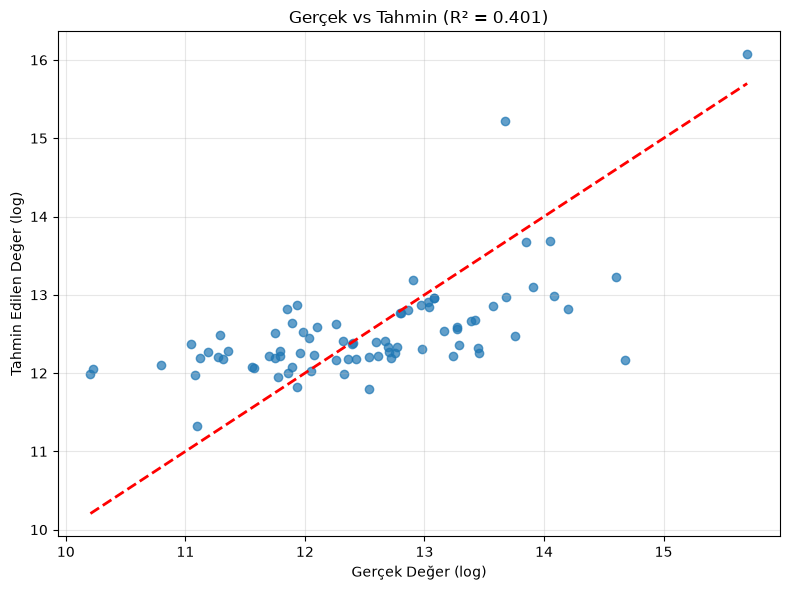

In [43]:
# Tahmin vs Gerçek değerleri görselleştir
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y, y_pred, alpha=0.7)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
ax.set_xlabel('Gerçek Değer (log)')
ax.set_ylabel('Tahmin Edilen Değer (log)')
ax.set_title(f'Gerçek vs Tahmin (R² = {r2:.3f})')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [44]:
# ============================================
# 8. KÜMELEME - K-MEANS
# ============================================

print("\n" + "="*70)
print("📊 KÜMELEME: İlleri Kütüphane Kullanımına Göre Gruplama")
print("="*70)

# Kümeleme için değişkenleri seç
kmeans_cols = ['Kütüphane_Sayısı', 'Yararlanan_Kişi', 'Kisi_Basi_Kitap', 'Odunc_Oran']
X_kmeans = df_merged[kmeans_cols].copy()

# Verileri temizle ve standartlaştır
X_kmeans = X_kmeans.replace([np.inf, -np.inf], 0)
X_kmeans = X_kmeans.fillna(0)

scaler_kmeans = StandardScaler()
X_kmeans_scaled = scaler_kmeans.fit_transform(X_kmeans)

# K-Means modeli (4 küme)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_merged['Kume'] = kmeans.fit_predict(X_kmeans_scaled)

# Küme istatistiklerini göster
print("\n📊 Küme İstatistikleri:")
for k in range(4):
    kume_data = df_merged[df_merged['Kume'] == k]
    print(f"\n   🏷️  Küme {k}: {len(kume_data)} il")
    print(f"   - Ortalama Kütüphane: {kume_data['Kütüphane_Sayısı'].mean():.1f}")
    print(f"   - Ortalama Yararlanıcı: {kume_data['Yararlanan_Kişi'].mean():.0f}")
    print(f"   - Kişi Başı Kitap: {kume_data['Kisi_Basi_Kitap'].mean():.3f}")
    print(f"   - Örnek iller: {', '.join(kume_data['İl'].head(3).tolist())}...")


📊 KÜMELEME: İlleri Kütüphane Kullanımına Göre Gruplama

📊 Küme İstatistikleri:

   🏷️  Küme 0: 34 il
   - Ortalama Kütüphane: 13.0
   - Ortalama Yararlanıcı: 254654
   - Kişi Başı Kitap: 0.808
   - Örnek iller: Amasya, Artvin, Bilecik...

   🏷️  Küme 1: 5 il
   - Ortalama Kütüphane: 41.6
   - Ortalama Yararlanıcı: 1332224
   - Kişi Başı Kitap: 0.285
   - Örnek iller: Ankara, İzmir, Kayseri...

   🏷️  Küme 2: 41 il
   - Ortalama Kütüphane: 14.0
   - Ortalama Yararlanıcı: 421895
   - Kişi Başı Kitap: 0.305
   - Örnek iller: Adana, Adıyaman, Afyonkarahisar...

   🏷️  Küme 3: 1 il
   - Ortalama Kütüphane: 76.0
   - Ortalama Yararlanıcı: 6577638
   - Kişi Başı Kitap: 0.199
   - Örnek iller: İstanbul...


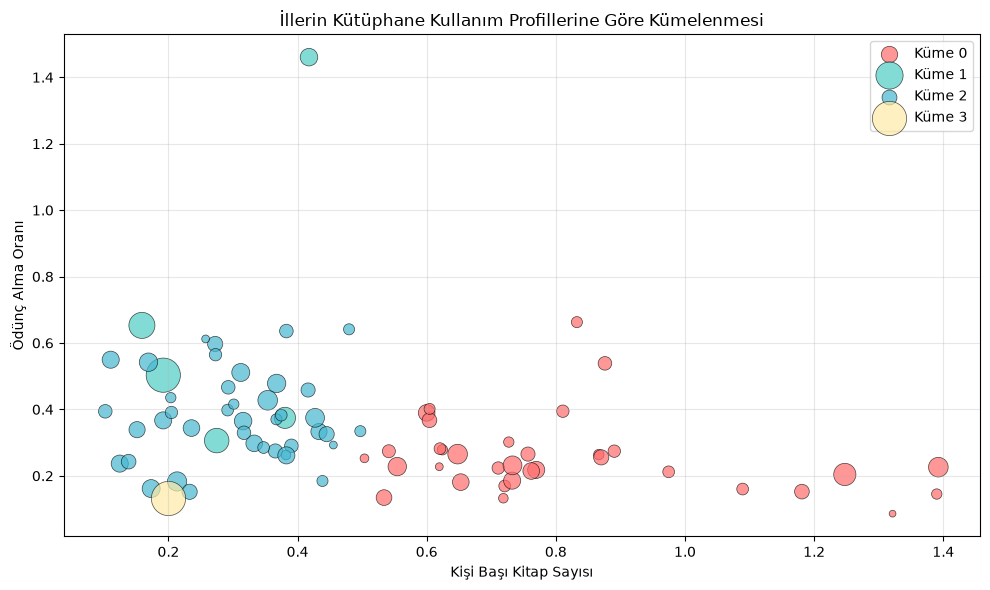

In [45]:
# Küme görselleştirme
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFEAA7']

for k in range(4):
    kume_data = df_merged[df_merged['Kume'] == k]
    ax.scatter(kume_data['Kisi_Basi_Kitap'], kume_data['Odunc_Oran'], 
               label=f'Küme {k}', alpha=0.7, s=kume_data['Kütüphane_Sayısı']*8,
               c=colors[k], edgecolors='black', linewidth=0.5)

ax.set_xlabel('Kişi Başı Kitap Sayısı')
ax.set_ylabel('Ödünç Alma Oranı')
ax.set_title('İllerin Kütüphane Kullanım Profillerine Göre Kümelenmesi')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [46]:
# ============================================
# 9. PROJE ÖZETİ
# ============================================

print("\n" + "="*70)
print("📋 PROJE ÖZETİ")
print("="*70)

print(f"""
✅ Toplam {len(df_merged)} il analiz edildi.
✅ Ortalama nüfus: {df_merged['Toplam_Nüfus'].mean():,.0f}
✅ Ortalama kütüphane sayısı: {df_merged['Kütüphane_Sayısı'].mean():.1f}
✅ Toplam kitap sayısı: {df_merged['Toplam_Kitap'].sum():,}
✅ Toplam yararlanıcı: {df_merged['Yararlanan_Kişi'].sum():,}

🎯 Model Performansı:
   • R² Skor: {r2:.3f} - Değişkenler kütüphane kullanımının %{r2*100:.1f}'ini açıklıyor
   • En etkili değişken: {X.columns[np.argmax(np.abs(model.coef_))]}

🏆 Bulgular:
   • Nüfus yoğunluğu ile kütüphane kullanımı arasında {corr:.3f} korelasyon var
   • En çok kitap türü: {max(kitap_turleri, key=kitap_turleri.get)}
   • En çok kitap olan il: {df_merged.loc[df_merged['Toplam_Kitap'].idxmax(), 'İl']}
""")

print("="*70)
print("🎉 PROJE BAŞARIYLA TAMAMLANDI!")
print("="*70)


📋 PROJE ÖZETİ

✅ Toplam 81 il analiz edildi.
✅ Ortalama nüfus: 1,062,866
✅ Ortalama kütüphane sayısı: 16.1
✅ Toplam kitap sayısı: 26,041,029
✅ Toplam yararlanıcı: 39,194,669

🎯 Model Performansı:
   • R² Skor: 0.401 - Değişkenler kütüphane kullanımının %40.1'ini açıklıyor
   • En etkili değişken: Toplam_Kitap

🏆 Bulgular:
   • Nüfus yoğunluğu ile kütüphane kullanımı arasında 0.820 korelasyon var
   • En çok kitap türü: Edebiyat
   • En çok kitap olan il: İstanbul

🎉 PROJE BAŞARIYLA TAMAMLANDI!
